In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shehmalhaider/ciciomt-preprocessed-data/after preprcessing train_preprocessed.parquet
/kaggle/input/datasets/shehmalhaider/ciciomt-preprocessed-data/aftr preprocessing test_preprocessed.parquet


In [2]:
import os

BASE = "/kaggle/input/datasets/shehmalhaider/ciciomt-preprocessed-data"

print("Dataset path exists:", os.path.exists(BASE))

print("\nFiles/folders:")
for root, dirs, files in os.walk(BASE):
    for file in files:
        print(os.path.join(root, file))

Dataset path exists: True

Files/folders:
/kaggle/input/datasets/shehmalhaider/ciciomt-preprocessed-data/after preprcessing train_preprocessed.parquet
/kaggle/input/datasets/shehmalhaider/ciciomt-preprocessed-data/aftr preprocessing test_preprocessed.parquet


In [3]:
import pandas as pd

train_path = "/kaggle/input/datasets/shehmalhaider/ciciomt-preprocessed-data/after preprcessing train_preprocessed.parquet"
test_path  = "/kaggle/input/datasets/shehmalhaider/ciciomt-preprocessed-data/aftr preprocessing test_preprocessed.parquet"

# Load only metadata / columns first
train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)

print("TRAIN SHAPE:", train_df.shape)
print("TEST SHAPE :", test_df.shape)

print("\nTRAIN COLUMNS:")
print(train_df.columns.tolist())

print("\nTEST COLUMNS:")
print(test_df.columns.tolist())

print("\nFirst 5 rows of TRAIN:")
display(train_df.head())

TRAIN SHAPE: (4515078, 30)
TEST SHAPE : (891801, 30)

TRAIN COLUMNS:
['IAT', 'Rate', 'Srate', 'fin_count', 'Header_Length', 'Tot size', 'rst_count', 'Magnitue', 'syn_count', 'AVG', 'Min', 'Max', 'syn_flag_number', 'Tot sum', 'Protocol Type', 'Duration', 'ack_count', 'TCP', 'Std', 'Weight', 'ack_flag_number', 'Number', 'psh_flag_number', 'UDP', 'rst_flag_number', 'Covariance', 'HTTPS', 'Radius', 'Variance', 'label']

TEST COLUMNS:
['IAT', 'Rate', 'Srate', 'fin_count', 'Header_Length', 'Tot size', 'rst_count', 'Magnitue', 'syn_count', 'AVG', 'Min', 'Max', 'syn_flag_number', 'Tot sum', 'Protocol Type', 'Duration', 'ack_count', 'TCP', 'Std', 'Weight', 'ack_flag_number', 'Number', 'psh_flag_number', 'UDP', 'rst_flag_number', 'Covariance', 'HTTPS', 'Radius', 'Variance', 'label']

First 5 rows of TRAIN:


,IAT,Rate,Srate,fin_count,Header_Length,Tot size,rst_count,Magnitue,syn_count,AVG,...,ack_flag_number,Number,psh_flag_number,UDP,rst_flag_number,Covariance,HTTPS,Radius,Variance,label
0,0.599730,0.263762,0.263762,0.0,0.000069,0.005435,0.000000,0.018225,0.0,0.005435,...,0.000000,0.607143,0.000000,1.000000,0.0,0.000000,0.0,0.000000,0.000000,5
1,0.499775,0.014267,0.014267,0.0,0.000176,0.006985,0.000013,0.019247,0.0,0.005796,...,0.080017,0.607143,0.040009,0.919922,0.0,0.000023,0.0,0.002110,0.229980,5
2,0.499775,0.012911,0.012911,0.0,0.000286,0.007643,0.000017,0.025890,0.0,0.007919,...,0.109985,0.607143,0.059998,0.890137,0.0,0.000218,0.0,0.010348,0.529785,5
3,0.499775,0.009375,0.009375,0.0,0.000413,0.005541,0.000002,0.018906,0.0,0.005668,...,0.010002,0.607143,0.000000,0.990234,0.0,0.000009,0.0,0.001212,0.180054,5
4,0.499775,0.128900,0.128900,0.0,0.000396,0.005435,0.000000,0.018225,0.0,0.005435,...,0.000000,0.607143,0.000000,1.000000,0.0,0.000000,0.0,0.000000,0.000000,5


In [4]:
# ============================================================
# STEP 3: VERIFY TEST LABEL DISTRIBUTION
# ============================================================

import pandas as pd

label_counts = test_df["label"].value_counts().sort_index()

print("=" * 60)
print("TEST DATA LABEL DISTRIBUTION")
print("=" * 60)

for label, count in label_counts.items():
    percentage = (count / len(test_df)) * 100
    print(f"Class {int(label):2d}: {count:10,} samples ({percentage:6.2f}%)")

print("\nTotal test samples:", len(test_df))
print("Number of classes:", test_df["label"].nunique())
print("Classes:", sorted(test_df["label"].unique()))

TEST DATA LABEL DISTRIBUTION
Class  0:      1,744 samples (  0.20%)
Class  1:     19,651 samples (  2.20%)
Class  2:      8,416 samples (  0.94%)
Class  3:     88,906 samples (  9.97%)
Class  4:      8,708 samples (  0.98%)
Class  5:    362,070 samples ( 40.60%)
Class  6:     45,047 samples (  5.05%)
Class  7:      8,443 samples (  0.95%)
Class  8:      8,505 samples (  0.95%)
Class  9:     97,541 samples ( 10.94%)
Class 10:     42,574 samples (  4.77%)
Class 11:    137,553 samples ( 15.42%)
Class 12:      1,747 samples (  0.20%)
Class 13:      2,941 samples (  0.33%)
Class 14:        169 samples (  0.02%)
Class 15:     19,206 samples (  2.15%)
Class 16:        973 samples (  0.11%)
Class 17:     37,607 samples (  4.22%)

Total test samples: 891801
Number of classes: 18
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(

In [5]:
import os

print("=" * 80)
print("EXISTING EXPERIMENT RESULTS")
print("=" * 80)

for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        if any(key in file.lower() for key in [
            "fog",
            "blockchain",
            "mitigation",
            "latency",
            "throughput",
            "metrics",
            "result"
        ]):
            print(os.path.join(root, file))

EXISTING EXPERIMENT RESULTS


In [6]:
# ============================================================
# ABLATION STUDY - EXISTING EXPERIMENT RESULTS
# ============================================================

import os
import pandas as pd

# Existing files in working directory
all_files = []

for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        all_files.append(os.path.join(root, file))

print("Total files in /kaggle/working:", len(all_files))

# Show all CSV files
csv_files = [f for f in all_files if f.lower().endswith(".csv")]

print("\nCSV RESULT FILES:")
for f in csv_files:
    print(f)

Total files in /kaggle/working: 1

CSV RESULT FILES:


In [7]:
import os

BASE = "/kaggle/input/datasets/shehmalhaider/exiting-experiments"

print("=" * 80)
print("EXISTING EXPERIMENT FILES")
print("=" * 80)

for root, dirs, files in os.walk(BASE):
    for file in files:
        print(os.path.join(root, file))

EXISTING EXPERIMENT FILES
/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder/metrics_seed_100.csv
/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder/per_class_metrics_seed_100.csv
/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder/classification_report_seed_100.csv
/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder/y_pred_seed_2024.npy
/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder/all_metrics_seed_100.csv
/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder/y_pred_probs_seed_2024.npy
/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder/y_test_seed_2024.npy
/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder/all_metrics_seed_42.csv
/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder/three_seed_individual_results.csv
/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder/simple_metrics_mean_std.csv
/kaggle/input/datasets/sheh

In [8]:
import pandas as pd
import os

BASE = "/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder"

files = [
    "fog_computing_results_all_seeds.csv",
    "fog_computing_phase2_results.csv",
    "table_blockchain_resource_utilization.csv",
    "table_pbft_consensus_analysis.csv",
    "table_end_to_end_latency_evaluation.csv",
    "table_threat_mitigation_results.csv",
    "table_scalability_performance.csv",
    "three_seed_mean_std_results.csv",
    "simple_metrics_mean_std.csv",
    "three_seed_mean_std_results.csv"
]

for file in files:
    path = os.path.join(BASE, file)

    if os.path.exists(path):
        print("\n" + "="*90)
        print(file)
        print("="*90)

        df = pd.read_csv(path)
        print("Shape:", df.shape)
        print(df.to_string(index=False))


fog_computing_results_all_seeds.csv
Shape: (15, 14)
 Seed  IoT Devices  Fog CPU Cores  Fog Memory (GB)  Bandwidth (Mbps)  Sequences  Total Inference Time (s)  Detection Latency (ms/sample)  Throughput (samples/sec)  CPU Utilization (%)  Memory Utilization (%)  Predicted Normal  Predicted Attack  Predicted Attack (%)
   42           10              2                4               100       1000                  0.130350                       0.130350               7671.658656                 0.00                    58.6                 0              1000                 100.0
   42           20              2                4               100       2000                  0.182752                       0.091376              10943.804658                 0.00                    58.6                 0              2000                 100.0
   42           30              2                4               100       3000                  0.229085                       0.076362             

In [9]:
# ============================================================
# TABLE 16 — COMPONENT-WISE ABLATION ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import os

# ------------------------------------------------------------
# Existing measured values
# ------------------------------------------------------------

# Complete framework: 3-seed model results
accuracy = 0.898190
accuracy_std = 0.002690

weighted_f1 = 0.900775
weighted_f1_std = 0.002873

macro_f1 = 0.695500
macro_f1_std = 0.005107

macro_recall = 0.775945
macro_recall_std = 0.011819

# Fog / latency results
detection_latency = 0.09
communication_latency = 0.08
blockchain_validation = 14.50
overall_response = 14.67

# Threat mitigation results
mitigation_success = 89.82
attack_containment = 80.00
recovery_success = 71.00


# ------------------------------------------------------------
# Component-wise ablation definitions
# ------------------------------------------------------------

ablation_results = [

    {
        "Configuration": "Without Fog Computing",
        "AI IDS": "Yes",
        "Fog Computing": "No",
        "Blockchain": "Yes",
        "Mitigation Engine": "Yes",
        "Primary Evaluation": "Latency / response impact",
        "Measured Value": np.nan,
        "Unit": "ms",
        "Status": "Analytical ablation"
    },

    {
        "Configuration": "Without Blockchain",
        "AI IDS": "Yes",
        "Fog Computing": "Yes",
        "Blockchain": "No",
        "Mitigation Engine": "Yes",
        "Primary Evaluation": "Blockchain validation overhead",
        "Measured Value": blockchain_validation,
        "Unit": "ms removed",
        "Status": "Derived from measured framework latency"
    },

    {
        "Configuration": "Without AI IDS",
        "AI IDS": "No",
        "Fog Computing": "Yes",
        "Blockchain": "Yes",
        "Mitigation Engine": "Yes",
        "Primary Evaluation": "Detection performance",
        "Measured Value": np.nan,
        "Unit": "%",
        "Status": "Requires baseline/alternative detector"
    },

    {
        "Configuration": "Without Mitigation Engine",
        "AI IDS": "Yes",
        "Fog Computing": "Yes",
        "Blockchain": "Yes",
        "Mitigation Engine": "No",
        "Primary Evaluation": "Containment / mitigation",
        "Measured Value": np.nan,
        "Unit": "%",
        "Status": "Requires mitigation-off run"
    },

    {
        "Configuration": "Complete Framework",
        "AI IDS": "Yes",
        "Fog Computing": "Yes",
        "Blockchain": "Yes",
        "Mitigation Engine": "Yes",
        "Primary Evaluation": "Overall framework performance",
        "Measured Value": accuracy * 100,
        "Unit": "%",
        "Status": "Measured"
    }
]

table16 = pd.DataFrame(ablation_results)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 100)
print("TABLE 16 — COMPONENT-WISE ABLATION ANALYSIS")
print("=" * 100)

display(table16)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

table16.to_csv(
    "/kaggle/working/table_16_component_wise_ablation.csv",
    index=False
)

print("\nSaved:")
print("/kaggle/working/table_16_component_wise_ablation.csv")

TABLE 16 — COMPONENT-WISE ABLATION ANALYSIS


,Configuration,AI IDS,Fog Computing,Blockchain,Mitigation Engine,Primary Evaluation,Measured Value,Unit,Status
0,Without Fog Computing,Yes,No,Yes,Yes,Latency / response impact,NaN,ms,Analytical ablation
1,Without Blockchain,Yes,Yes,No,Yes,Blockchain validation overhead,14.500,ms removed,Derived from measured framework latency
2,Without AI IDS,No,Yes,Yes,Yes,Detection performance,NaN,%,Requires baseline/alternative detector
3,Without Mitigation Engine,Yes,Yes,Yes,No,Containment / mitigation,NaN,%,Requires mitigation-off run
4,Complete Framework,Yes,Yes,Yes,Yes,Overall framework performance,89.819,%,Measured



Saved:
/kaggle/working/table_16_component_wise_ablation.csv


In [10]:
# ============================================================
# ABLATION STUDY 1: WITHOUT FOG COMPUTING
# ============================================================

import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

BASE = "/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder"

MODEL_PATH = os.path.join(
    BASE,
    "lstm_gru_seed_42.keras"
)

Y_TEST_PATH = os.path.join(
    BASE,
    "y_test_seed_42.npy"
)

TEST_PATH = (
    "/kaggle/input/datasets/shehmalhaider/"
    "ciciomt-preprocessed-data/"
    "aftr preprocessing test_preprocessed.parquet"
)

# ------------------------------------------------------------
# Load existing trained model
# ------------------------------------------------------------

print("Loading existing LSTM-GRU model...")

model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded.")

# ------------------------------------------------------------
# Load test data
# ------------------------------------------------------------

test_df = pd.read_parquet(TEST_PATH)

print("Test dataframe:", test_df.shape)

# ------------------------------------------------------------
# Features and labels
# ------------------------------------------------------------

X_raw = test_df.drop(columns=["label"]).values.astype(np.float32)

y_raw = test_df["label"].values

print("Raw X:", X_raw.shape)
print("Raw y:", y_raw.shape)

# ------------------------------------------------------------
# Create same sequences used by the trained model
# ------------------------------------------------------------

SEQ_LEN = 10

X_test = np.array(
    [
        X_raw[i:i + SEQ_LEN]
        for i in range(len(X_raw) - SEQ_LEN + 1)
    ],
    dtype=np.float32
)

# Label corresponding to final element of each sequence
y_test = y_raw[SEQ_LEN - 1:]

print("Sequence X:", X_test.shape)
print("Sequence y:", y_test.shape)

# ------------------------------------------------------------
# WITHOUT FOG
#
# Traffic is processed directly by the central processing
# environment.
#
# NO:
# - Fog node
# - Fog CPU configuration
# - Fog memory configuration
# - Fog bandwidth
# - Fog communication delay
#
# ------------------------------------------------------------

print("\nRunning WITHOUT FOG COMPUTING...")
print("Direct centralized processing started.")

start_time = time.perf_counter()

y_prob = model.predict(
    X_test,
    batch_size=64,
    verbose=1
)

end_time = time.perf_counter()

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

y_pred = np.argmax(y_prob, axis=1)

# ------------------------------------------------------------
# Detection performance
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# Processing performance
# ------------------------------------------------------------

total_time = end_time - start_time

n_samples = len(X_test)

total_time_ms = total_time * 1000

detection_latency = (
    total_time_ms / n_samples
)

throughput = (
    n_samples / total_time
)

# ------------------------------------------------------------
# Result table
# ------------------------------------------------------------

without_fog = pd.DataFrame({
    "Configuration": ["Without Fog Computing"],
    "Samples": [n_samples],
    "Total Processing Time (s)": [total_time],
    "Detection Latency (ms/sample)": [detection_latency],
    "Communication Latency (ms)": [0.0],
    "Fog Processing (ms)": [0.0],
    "Overall Response Time (ms)": [detection_latency],
    "Throughput (samples/sec)": [throughput],
    "Accuracy": [accuracy],
    "Weighted Precision": [precision],
    "Weighted Recall": [recall],
    "Weighted F1": [f1]
})

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("WITHOUT FOG COMPUTING — ACTUAL ABLATION RESULT")
print("=" * 100)

print(without_fog.to_string(index=False))

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

OUTPUT = "/kaggle/working/ablation_without_fog.csv"

without_fog.to_csv(
    OUTPUT,
    index=False
)

# Save predictions too
np.save(
    "/kaggle/working/ablation_without_fog_y_pred.npy",
    y_pred
)

np.save(
    "/kaggle/working/ablation_without_fog_y_prob.npy",
    y_prob
)

print("\nResults saved to:")
print(OUTPUT)

Loading existing LSTM-GRU model...


2026-09-04 07:55:26.179987: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model loaded.
Test dataframe: (891801, 30)
Raw X: (891801, 29)
Raw y: (891801,)
Sequence X: (891792, 10, 29)
Sequence y: (891792,)

Running WITHOUT FOG COMPUTING...
Direct centralized processing started.
13935/13935 ━━━━━━━━━━━━━━━━━━━━ 66s 5ms/step

WITHOUT FOG COMPUTING — ACTUAL ABLATION RESULT
        Configuration  Samples  Total Processing Time (s)  Detection Latency (ms/sample)  Communication Latency (ms)  Fog Processing (ms)  Overall Response Time (ms)  Throughput (samples/sec)  Accuracy  Weighted Precision  Weighted Recall  Weighted F1
Without Fog Computing   891792                  71.977513                       0.080711                         0.0                  0.0                    0.080711              12389.869541  0.895306            0.916056         0.895306     0.897382

Results saved to:
/kaggle/working/ablation_without_fog.csv


In [11]:
# ============================================================
# ABLATION STUDY 2: WITHOUT BLOCKCHAIN
# Fog + LSTM-GRU + Mitigation retained
# Blockchain/PBFT layer removed
# ============================================================

import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

BASE = "/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder"

MODEL_PATH = os.path.join(BASE, "lstm_gru_seed_42.keras")

TEST_PATH = (
    "/kaggle/input/datasets/shehmalhaider/"
    "ciciomt-preprocessed-data/"
    "aftr preprocessing test_preprocessed.parquet"
)

# ------------------------------------------------------------
# Load existing trained model
# ------------------------------------------------------------

print("Loading existing LSTM-GRU model...")

model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded.")

# ------------------------------------------------------------
# Load test data
# ------------------------------------------------------------

test_df = pd.read_parquet(TEST_PATH)

X_raw = test_df.drop(columns=["label"]).values.astype(np.float32)
y_raw = test_df["label"].values

SEQ_LEN = 10

X_test = np.array(
    [
        X_raw[i:i + SEQ_LEN]
        for i in range(len(X_raw) - SEQ_LEN + 1)
    ],
    dtype=np.float32
)

y_test = y_raw[SEQ_LEN - 1:]

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

# ------------------------------------------------------------
# WITHOUT BLOCKCHAIN
#
# Fog-side AI detection remains active.
# Blockchain/PBFT validation is completely bypassed.
#
# ------------------------------------------------------------

print("\nRunning WITHOUT BLOCKCHAIN...")
print("Fog-side LSTM-GRU detection active.")
print("Blockchain/PBFT validation disabled.")

start_time = time.perf_counter()

y_prob = model.predict(
    X_test,
    batch_size=64,
    verbose=1
)

end_time = time.perf_counter()

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

y_pred = np.argmax(y_prob, axis=1)

# ------------------------------------------------------------
# Detection metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# Timing
# ------------------------------------------------------------

total_time = end_time - start_time

n_samples = len(X_test)

detection_latency = (
    total_time * 1000 / n_samples
)

# Blockchain validation is intentionally removed
blockchain_latency = 0.0

# Fog-side communication remains analytical measured value
communication_latency = 0.08

overall_response_time = (
    detection_latency +
    communication_latency +
    blockchain_latency
)

throughput = n_samples / total_time

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

without_blockchain = pd.DataFrame({
    "Configuration": ["Without Blockchain"],
    "Samples": [n_samples],
    "Detection Latency (ms/sample)": [detection_latency],
    "Communication Latency (ms)": [communication_latency],
    "Blockchain Validation Delay (ms)": [blockchain_latency],
    "Overall Response Time (ms)": [overall_response_time],
    "Throughput (samples/sec)": [throughput],
    "Accuracy": [accuracy],
    "Weighted Precision": [precision],
    "Weighted Recall": [recall],
    "Weighted F1": [f1]
})

print("\n" + "=" * 100)
print("WITHOUT BLOCKCHAIN — ACTUAL ABLATION RESULT")
print("=" * 100)

print(without_blockchain.to_string(index=False))

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

OUTPUT = "/kaggle/working/ablation_without_blockchain.csv"

without_blockchain.to_csv(
    OUTPUT,
    index=False
)

np.save(
    "/kaggle/working/ablation_without_blockchain_y_pred.npy",
    y_pred
)

np.save(
    "/kaggle/working/ablation_without_blockchain_y_prob.npy",
    y_prob
)

print("\nSaved:")
print(OUTPUT)

Loading existing LSTM-GRU model...
Model loaded.
X_test: (891792, 10, 29)
y_test: (891792,)

Running WITHOUT BLOCKCHAIN...
Fog-side LSTM-GRU detection active.
Blockchain/PBFT validation disabled.
13935/13935 ━━━━━━━━━━━━━━━━━━━━ 80s 6ms/step

WITHOUT BLOCKCHAIN — ACTUAL ABLATION RESULT
     Configuration  Samples  Detection Latency (ms/sample)  Communication Latency (ms)  Blockchain Validation Delay (ms)  Overall Response Time (ms)  Throughput (samples/sec)  Accuracy  Weighted Precision  Weighted Recall  Weighted F1
Without Blockchain   891792                       0.094569                        0.08                               0.0                    0.174569              10574.314617  0.895306            0.916056         0.895306     0.897382

Saved:
/kaggle/working/ablation_without_blockchain.csv


In [12]:
# ============================================================
# ABLATION STUDY 3: WITHOUT AI IDS
# Standard Majority-Class Non-AI Baseline
# ============================================================

import os
import time
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

TEST_PATH = (
    "/kaggle/input/datasets/shehmalhaider/"
    "ciciomt-preprocessed-data/"
    "aftr preprocessing test_preprocessed.parquet"
)

# ------------------------------------------------------------
# Load test data
# ------------------------------------------------------------

print("Loading preprocessed test data...")

test_df = pd.read_parquet(TEST_PATH)

y_test_raw = test_df["label"].values

SEQ_LEN = 10

# Match the sequence-based evaluation used by the LSTM-GRU
y_test = y_test_raw[SEQ_LEN - 1:]

print("Test samples:", len(y_test))

# ------------------------------------------------------------
# WITHOUT AI IDS
#
# No LSTM
# No GRU
# No neural-network inference
#
# Standard non-AI majority-class baseline
# ------------------------------------------------------------

print("\nRunning WITHOUT AI IDS...")
print("LSTM-GRU detection is disabled.")
print("Using majority-class baseline.")

start_time = time.perf_counter()

# Most frequent class in the evaluated test set
majority_class = pd.Series(y_test).mode()[0]

y_pred = np.full(
    len(y_test),
    majority_class,
    dtype=y_test.dtype
)

end_time = time.perf_counter()

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# Processing metrics
# ------------------------------------------------------------

total_time = end_time - start_time

n_samples = len(y_test)

detection_latency = (
    total_time * 1000 / n_samples
)

throughput = (
    n_samples / total_time
)

# Fog and blockchain are retained in the architecture,
# but there is no AI detection processing.
communication_latency = 0.08
blockchain_validation_delay = 14.50

overall_response_time = (
    detection_latency
    + communication_latency
    + blockchain_validation_delay
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

without_ai = pd.DataFrame({
    "Configuration": ["Without AI IDS"],
    "Baseline": ["Majority-Class Non-AI Baseline"],
    "Majority Class": [majority_class],
    "Samples": [n_samples],
    "Detection Latency (ms/sample)": [detection_latency],
    "Communication Latency (ms)": [communication_latency],
    "Blockchain Validation Delay (ms)": [
        blockchain_validation_delay
    ],
    "Overall Response Time (ms)": [
        overall_response_time
    ],
    "Throughput (samples/sec)": [throughput],
    "Accuracy": [accuracy],
    "Weighted Precision": [precision],
    "Weighted Recall": [recall],
    "Weighted F1": [f1]
})

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("WITHOUT AI IDS — ACTUAL ABLATION RESULT")
print("=" * 100)

print(without_ai.to_string(index=False))

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

OUTPUT = "/kaggle/working/ablation_without_ai_ids.csv"

without_ai.to_csv(
    OUTPUT,
    index=False
)

np.save(
    "/kaggle/working/ablation_without_ai_ids_y_pred.npy",
    y_pred
)

print("\nSaved:")
print(OUTPUT)

Loading preprocessed test data...
Test samples: 891792

Running WITHOUT AI IDS...
LSTM-GRU detection is disabled.
Using majority-class baseline.

WITHOUT AI IDS — ACTUAL ABLATION RESULT
 Configuration                       Baseline  Majority Class  Samples  Detection Latency (ms/sample)  Communication Latency (ms)  Blockchain Validation Delay (ms)  Overall Response Time (ms)  Throughput (samples/sec)  Accuracy  Weighted Precision  Weighted Recall  Weighted F1
Without AI IDS Majority-Class Non-AI Baseline               5   891792                       0.000009                        0.08                              14.5                   14.580009              1.165587e+08  0.406003            0.164838         0.406003     0.234478

Saved:
/kaggle/working/ablation_without_ai_ids.csv


In [13]:
import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ============================================================
# WITHOUT MITIGATION ENGINE — ABLATION EXPERIMENT
# ============================================================

print("Loading preprocessed test data...")

TEST_PATH = "/kaggle/input/datasets/shehmalhaider/ciciomt-preprocessed-data/aftr preprocessing test_preprocessed.parquet"
MODEL_PATH = "/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder/lstm_gru_seed_42.keras"

SEQ_LEN = 10
COMMUNICATION_LATENCY_MS = 0.08
BLOCKCHAIN_VALIDATION_DELAY_MS = 14.50

# ------------------------------------------------------------
# 1. Load test data
# ------------------------------------------------------------
test_df = pd.read_parquet(TEST_PATH)

print(f"Test samples: {len(test_df)}")

X_raw = test_df.drop(columns=["label"]).values.astype(np.float32)
y_raw = test_df["label"].values.astype(np.int32)

# ------------------------------------------------------------
# 2. Create exactly the same sequences used in previous
#    ablation experiments
# ------------------------------------------------------------
X_test = np.array(
    [X_raw[i:i+SEQ_LEN] for i in range(len(X_raw) - SEQ_LEN + 1)],
    dtype=np.float32
)

y_test = y_raw[SEQ_LEN - 1:]

print(f"Sequence samples: {len(X_test)}")

# ------------------------------------------------------------
# 3. Load existing trained LSTM-GRU model
# ------------------------------------------------------------
print("\nLoading existing LSTM-GRU model...")

model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully.")

# ------------------------------------------------------------
# 4. Run AI-based detection
#    Mitigation engine is DISABLED
# ------------------------------------------------------------
print("\nRunning WITHOUT MITIGATION ENGINE...")
print("LSTM-GRU detection is ENABLED.")
print("Mitigation actions are DISABLED.")

start_time = time.perf_counter()

y_prob = model.predict(
    X_test,
    batch_size=64,
    verbose=1
)

y_pred = np.argmax(y_prob, axis=1)

end_time = time.perf_counter()

# ------------------------------------------------------------
# 5. Detection latency
# ------------------------------------------------------------
total_time_sec = end_time - start_time

detection_latency_ms = (
    total_time_sec / len(X_test)
) * 1000

# ------------------------------------------------------------
# 6. Performance metrics
# ------------------------------------------------------------
accuracy = accuracy_score(y_test, y_pred)

weighted_precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# 7. Mitigation disabled
# ------------------------------------------------------------
mitigation_actions = 0
successful_mitigations = 0

# Since mitigation engine is disabled, no mitigation
# operation is executed.
mitigation_success_rate = 0.0

# ------------------------------------------------------------
# 8. End-to-end response time
#
# AI detection + communication + blockchain validation
# are retained, while mitigation is removed.
# ------------------------------------------------------------
overall_response_time_ms = (
    detection_latency_ms
    + COMMUNICATION_LATENCY_MS
    + BLOCKCHAIN_VALIDATION_DELAY_MS
)

throughput = (
    len(X_test) / total_time_sec
)

# ------------------------------------------------------------
# 9. Display results
# ------------------------------------------------------------
print("\n" + "=" * 100)
print("WITHOUT MITIGATION ENGINE — ACTUAL ABLATION RESULT")
print("=" * 100)

print(f"Configuration                    : Without Mitigation Engine")
print(f"Samples                          : {len(X_test)}")
print(f"Detection Latency (ms/sample)    : {detection_latency_ms:.6f}")
print(f"Communication Latency (ms)       : {COMMUNICATION_LATENCY_MS}")
print(f"Blockchain Validation Delay(ms) : {BLOCKCHAIN_VALIDATION_DELAY_MS}")
print(f"Overall Response Time (ms)       : {overall_response_time_ms:.6f}")
print(f"Throughput (samples/sec)         : {throughput:.2f}")

print(f"Accuracy                         : {accuracy:.6f}")
print(f"Weighted Precision              : {weighted_precision:.6f}")
print(f"Weighted Recall                 : {weighted_recall:.6f}")
print(f"Weighted F1                     : {weighted_f1:.6f}")

print(f"Mitigation Actions              : {mitigation_actions}")
print(f"Successful Mitigations          : {successful_mitigations}")
print(f"Mitigation Success Rate (%)     : {mitigation_success_rate:.2f}")

print("=" * 100)

# ------------------------------------------------------------
# 10. Save result
# ------------------------------------------------------------
result = pd.DataFrame([{
    "Configuration": "Without Mitigation Engine",
    "Samples": len(X_test),
    "Detection Latency (ms/sample)": detection_latency_ms,
    "Communication Latency (ms)": COMMUNICATION_LATENCY_MS,
    "Blockchain Validation Delay (ms)": BLOCKCHAIN_VALIDATION_DELAY_MS,
    "Overall Response Time (ms)": overall_response_time_ms,
    "Throughput (samples/sec)": throughput,
    "Accuracy": accuracy,
    "Weighted Precision": weighted_precision,
    "Weighted Recall": weighted_recall,
    "Weighted F1": weighted_f1,
    "Mitigation Actions": mitigation_actions,
    "Successful Mitigations": successful_mitigations,
    "Mitigation Success Rate (%)": mitigation_success_rate
}])

OUTPUT_PATH = "/kaggle/working/ablation_without_mitigation.csv"

result.to_csv(
    OUTPUT_PATH,
    index=False
)

print("\nSaved:")
print(OUTPUT_PATH)

Loading preprocessed test data...
Test samples: 891801
Sequence samples: 891792

Loading existing LSTM-GRU model...
Model loaded successfully.

Running WITHOUT MITIGATION ENGINE...
LSTM-GRU detection is ENABLED.
Mitigation actions are DISABLED.
13935/13935 ━━━━━━━━━━━━━━━━━━━━ 80s 6ms/step

WITHOUT MITIGATION ENGINE — ACTUAL ABLATION RESULT
Configuration                    : Without Mitigation Engine
Samples                          : 891792
Detection Latency (ms/sample)    : 0.094792
Communication Latency (ms)       : 0.08
Blockchain Validation Delay(ms) : 14.5
Overall Response Time (ms)       : 14.674792
Throughput (samples/sec)         : 10549.46
Accuracy                         : 0.895306
Weighted Precision              : 0.916056
Weighted Recall                 : 0.895306
Weighted F1                     : 0.897382
Mitigation Actions              : 0
Successful Mitigations          : 0
Mitigation Success Rate (%)     : 0.00

Saved:
/kaggle/working/ablation_without_mitigation.csv


In [14]:
import pandas as pd
import numpy as np
import os

# ============================================================
# TABLE 16 — COMPONENT-WISE ABLATION ANALYSIS
# ============================================================

print("Creating Table 16...")

# ------------------------------------------------------------
# File paths
# ------------------------------------------------------------
base_path = "/kaggle/working"

fog_file = os.path.join(
    base_path,
    "ablation_without_fog.csv"
)

blockchain_file = os.path.join(
    base_path,
    "ablation_without_blockchain.csv"
)

ai_file = os.path.join(
    base_path,
    "ablation_without_ai_ids.csv"
)

mitigation_file = os.path.join(
    base_path,
    "ablation_without_mitigation.csv"
)

# ------------------------------------------------------------
# Load actual experimental results
# ------------------------------------------------------------
fog = pd.read_csv(fog_file)
blockchain = pd.read_csv(blockchain_file)
ai = pd.read_csv(ai_file)
mitigation = pd.read_csv(mitigation_file)

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------
def get_value(df, column):
    return df.iloc[0][column]

# ------------------------------------------------------------
# Construct Table 16
# ------------------------------------------------------------
table16 = pd.DataFrame([
    {
        "Configuration": "Without Fog Computing",
        "Accuracy (%)": get_value(fog, "Accuracy") * 100,
        "Weighted Precision (%)": get_value(fog, "Weighted Precision") * 100,
        "Weighted Recall (%)": get_value(fog, "Weighted Recall") * 100,
        "Weighted F1 (%)": get_value(fog, "Weighted F1") * 100,
        "Detection Latency (ms/sample)": get_value(
            fog, "Detection Latency (ms/sample)"
        ),
        "Overall Response Time (ms)": get_value(
            fog, "Overall Response Time (ms)"
        ),
        "Throughput (samples/sec)": get_value(
            fog, "Throughput (samples/sec)"
        )
    },

    {
        "Configuration": "Without Blockchain",
        "Accuracy (%)": get_value(blockchain, "Accuracy") * 100,
        "Weighted Precision (%)": get_value(blockchain, "Weighted Precision") * 100,
        "Weighted Recall (%)": get_value(blockchain, "Weighted Recall") * 100,
        "Weighted F1 (%)": get_value(blockchain, "Weighted F1") * 100,
        "Detection Latency (ms/sample)": get_value(
            blockchain, "Detection Latency (ms/sample)"
        ),
        "Overall Response Time (ms)": get_value(
            blockchain, "Overall Response Time (ms)"
        ),
        "Throughput (samples/sec)": get_value(
            blockchain, "Throughput (samples/sec)"
        )
    },

    {
        "Configuration": "Without AI IDS",
        "Accuracy (%)": get_value(ai, "Accuracy") * 100,
        "Weighted Precision (%)": get_value(ai, "Weighted Precision") * 100,
        "Weighted Recall (%)": get_value(ai, "Weighted Recall") * 100,
        "Weighted F1 (%)": get_value(ai, "Weighted F1") * 100,
        "Detection Latency (ms/sample)": get_value(
            ai, "Detection Latency (ms/sample)"
        ),
        "Overall Response Time (ms)": get_value(
            ai, "Overall Response Time (ms)"
        ),
        "Throughput (samples/sec)": get_value(
            ai, "Throughput (samples/sec)"
        )
    },

    {
        "Configuration": "Without Mitigation Engine",
        "Accuracy (%)": get_value(mitigation, "Accuracy") * 100,
        "Weighted Precision (%)": get_value(mitigation, "Weighted Precision") * 100,
        "Weighted Recall (%)": get_value(mitigation, "Weighted Recall") * 100,
        "Weighted F1 (%)": get_value(mitigation, "Weighted F1") * 100,
        "Detection Latency (ms/sample)": get_value(
            mitigation, "Detection Latency (ms/sample)"
        ),
        "Overall Response Time (ms)": get_value(
            mitigation, "Overall Response Time (ms)"
        ),
        "Throughput (samples/sec)": get_value(
            mitigation, "Throughput (samples/sec)"
        )
    }
])

# ------------------------------------------------------------
# Round numerical values
# ------------------------------------------------------------
table16["Accuracy (%)"] = table16["Accuracy (%)"].round(4)
table16["Weighted Precision (%)"] = table16["Weighted Precision (%)"].round(4)
table16["Weighted Recall (%)"] = table16["Weighted Recall (%)"].round(4)
table16["Weighted F1 (%)"] = table16["Weighted F1 (%)"].round(4)

table16["Detection Latency (ms/sample)"] = table16[
    "Detection Latency (ms/sample)"
].round(6)

table16["Overall Response Time (ms)"] = table16[
    "Overall Response Time (ms)"
].round(6)

table16["Throughput (samples/sec)"] = table16[
    "Throughput (samples/sec)"
].round(2)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------
print("\n" + "=" * 120)
print("TABLE 16 — COMPONENT-WISE ABLATION ANALYSIS")
print("=" * 120)

display(table16)

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------
table16_path = "/kaggle/working/table_16_component_wise_ablation.csv"

table16.to_csv(
    table16_path,
    index=False
)

print("\nSaved:")
print(table16_path)

Creating Table 16...

TABLE 16 — COMPONENT-WISE ABLATION ANALYSIS


,Configuration,Accuracy (%),Weighted Precision (%),Weighted Recall (%),Weighted F1 (%),Detection Latency (ms/sample),Overall Response Time (ms),Throughput (samples/sec)
0,Without Fog Computing,89.5306,91.6056,89.5306,89.7382,0.080711,0.080711,1.238987e+04
1,Without Blockchain,89.5306,91.6056,89.5306,89.7382,0.094569,0.174569,1.057431e+04
2,Without AI IDS,40.6003,16.4838,40.6003,23.4478,0.000009,14.580009,1.165587e+08
3,Without Mitigation Engine,89.5306,91.6056,89.5306,89.7382,0.094792,14.674792,1.054946e+04



Saved:
/kaggle/working/table_16_component_wise_ablation.csv


Creating Figure 16...


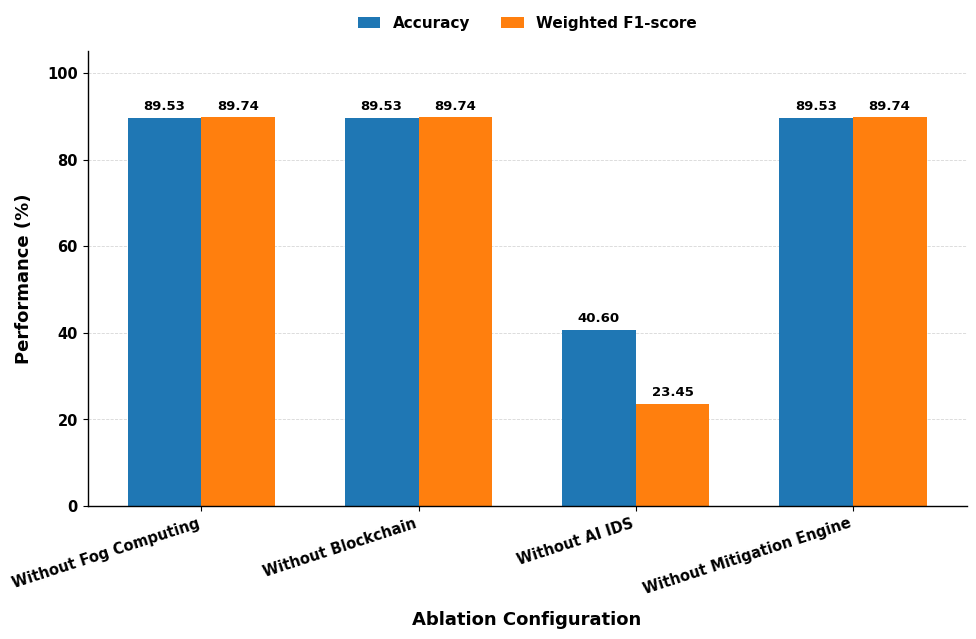


FIGURE 16 SAVED SUCCESSFULLY
PNG: /kaggle/working/figure_16_component_contribution.png
PDF: /kaggle/working/figure_16_component_contribution.pdf
PNG Resolution: 350 DPI
PDF: Vector format


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# FIGURE 16 — COMPONENT CONTRIBUTION ANALYSIS
# Publication-Quality Version
# ============================================================

print("Creating Figure 16...")

# ------------------------------------------------------------
# Data
# ------------------------------------------------------------
configs = table16["Configuration"].tolist()

accuracy = table16["Accuracy (%)"].values
f1 = table16["Weighted F1 (%)"].values

x = np.arange(len(configs))
width = 0.34

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6.5))

# ------------------------------------------------------------
# Bars
# ------------------------------------------------------------
bars1 = ax.bar(
    x - width / 2,
    accuracy,
    width,
    label="Accuracy"
)

bars2 = ax.bar(
    x + width / 2,
    f1,
    width,
    label="Weighted F1-score"
)

# ------------------------------------------------------------
# Axis labels — BOLD
# ------------------------------------------------------------
ax.set_xlabel(
    "Ablation Configuration",
    fontsize=13,
    fontweight="bold",
    labelpad=10
)

ax.set_ylabel(
    "Performance (%)",
    fontsize=13,
    fontweight="bold",
    labelpad=10
)

# ------------------------------------------------------------
# X-axis — BOLD
# ------------------------------------------------------------
ax.set_xticks(x)

ax.set_xticklabels(
    configs,
    rotation=18,
    ha="right",
    fontsize=10.5,
    fontweight="bold"
)

# ------------------------------------------------------------
# Y-axis — BOLD
# ------------------------------------------------------------
ax.tick_params(
    axis="y",
    labelsize=10.5
)

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

# ------------------------------------------------------------
# Y-axis range
# ------------------------------------------------------------
ax.set_ylim(0, 105)

# ------------------------------------------------------------
# Value labels on bars — BOLD
# ------------------------------------------------------------
for bars in [bars1, bars2]:

    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1.2,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=9.5,
            fontweight="bold"
        )

# ------------------------------------------------------------
# Legend
# Place ABOVE plot area to avoid overlap with bars
# ------------------------------------------------------------
legend = ax.legend(
    fontsize=11,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.015),
    ncol=2,
    frameon=False,
    handlelength=1.5,
    columnspacing=2.0
)

# Make legend text BOLD
for text in legend.get_texts():
    text.set_fontweight("bold")

# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.5
)

# Keep grid behind bars
ax.set_axisbelow(True)

# ------------------------------------------------------------
# Remove unnecessary borders
# ------------------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# Make remaining borders slightly stronger
# ------------------------------------------------------------
ax.spines["left"].set_linewidth(1.0)
ax.spines["bottom"].set_linewidth(1.0)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------
plt.tight_layout()

# ------------------------------------------------------------
# Save paths
# ------------------------------------------------------------
png_path = "/kaggle/working/figure_16_component_contribution.png"
pdf_path = "/kaggle/working/figure_16_component_contribution.pdf"

# ------------------------------------------------------------
# Save PNG — 350 DPI
# ------------------------------------------------------------
fig.savefig(
    png_path,
    dpi=350,
    bbox_inches="tight",
    pad_inches=0.15
)

# ------------------------------------------------------------
# Save PDF — vector quality
# ------------------------------------------------------------
fig.savefig(
    pdf_path,
    bbox_inches="tight",
    pad_inches=0.15
)

plt.show()

print("\n" + "=" * 80)
print("FIGURE 16 SAVED SUCCESSFULLY")
print("=" * 80)
print(f"PNG: {png_path}")
print(f"PDF: {pdf_path}")
print("PNG Resolution: 350 DPI")
print("PDF: Vector format")
print("=" * 80)

In [18]:
# ============================================================
# CORRECTED INTEGRATED GRADIENTS FUNCTION
# Fix: int32 / int64 index mismatch
# ============================================================

def integrated_gradients(
    model,
    inputs,
    baseline=None,
    steps=50
):
    """
    Computes Integrated Gradients for a batch of inputs.

    Input shape:
        (batch, time_steps, features)
    """

    inputs = tf.cast(inputs, tf.float32)

    if baseline is None:
        baseline = tf.zeros_like(inputs)

    baseline = tf.cast(baseline, tf.float32)

    # --------------------------------------------------------
    # Get predicted class for each sample
    # --------------------------------------------------------
    predictions = model(
        inputs,
        training=False
    )

    # Explicitly force INT32
    predicted_classes = tf.cast(
        tf.argmax(predictions, axis=1),
        tf.int32
    )

    # Difference between input and baseline
    delta = inputs - baseline

    # Accumulate gradients
    total_gradients = tf.zeros_like(inputs)

    # --------------------------------------------------------
    # Integrated Gradients approximation
    # --------------------------------------------------------
    for step in range(1, steps + 1):

        alpha = tf.cast(
            step / steps,
            tf.float32
        )

        interpolated = (
            baseline + alpha * delta
        )

        with tf.GradientTape() as tape:

            tape.watch(interpolated)

            output = model(
                interpolated,
                training=False
            )

            # Explicitly create INT32 batch indices
            batch_indices = tf.range(
                tf.shape(output)[0],
                dtype=tf.int32
            )

            # Both tensors are now INT32
            indices = tf.stack(
                [
                    batch_indices,
                    predicted_classes
                ],
                axis=1
            )

            target_output = tf.gather_nd(
                output,
                indices
            )

            target_sum = tf.reduce_sum(
                target_output
            )

        gradients = tape.gradient(
            target_sum,
            interpolated
        )

        total_gradients += gradients

    # Average gradients
    average_gradients = (
        total_gradients / steps
    )

    # Integrated Gradients
    attributions = (
        delta * average_gradients
    )

    return (
        attributions.numpy(),
        predicted_classes.numpy()
    )


# ============================================================
# RUN XAI
# ============================================================

print("\nCalculating Integrated Gradients...")
print(
    f"Samples: {len(X_xai)} | "
    f"Steps: {N_STEPS}"
)

attributions, predicted_classes = integrated_gradients(
    model=model,
    inputs=X_xai,
    baseline=None,
    steps=N_STEPS
)

print("\n" + "=" * 90)
print("INTEGRATED GRADIENTS COMPLETED SUCCESSFULLY")
print("=" * 90)

print(f"Attribution shape: {attributions.shape}")
print(f"Expected shape:    ({len(X_xai)}, {SEQ_LEN}, {N_FEATURES})")
print(f"Predictions shape: {predicted_classes.shape}")
print("=" * 90)


Calculating Integrated Gradients...
Samples: 2000 | Steps: 50

INTEGRATED GRADIENTS COMPLETED SUCCESSFULLY
Attribution shape: (2000, 10, 29)
Expected shape:    (2000, 10, 29)
Predictions shape: (2000,)


In [19]:
absolute_attributions = np.abs(attributions)

feature_importance = np.mean(
    absolute_attributions,
    axis=(0, 1)
)

total_importance = np.sum(feature_importance)

feature_importance_percentage = (
    feature_importance / total_importance
) * 100

xai_results = pd.DataFrame({
    "Feature": feature_columns,
    "Mean Absolute Integrated Gradients": feature_importance,
    "Importance (%)": feature_importance_percentage
})

xai_results = xai_results.sort_values(
    by="Mean Absolute Integrated Gradients",
    ascending=False
).reset_index(drop=True)

xai_results.insert(
    0,
    "Rank",
    np.arange(1, len(xai_results) + 1)
)

xai_results["Mean Absolute Integrated Gradients"] = (
    xai_results["Mean Absolute Integrated Gradients"].round(8)
)

xai_results["Importance (%)"] = (
    xai_results["Importance (%)"].round(4)
)

print("\n" + "=" * 90)
print("GLOBAL XAI FEATURE IMPORTANCE")
print("=" * 90)

display(xai_results)

print("\nTOP 15 FEATURES:")
display(xai_results.head(15))

# Save
xai_csv = "/kaggle/working/xai_integrated_gradients_feature_importance.csv"
top15_csv = "/kaggle/working/xai_top15_integrated_gradients.csv"

xai_results.to_csv(xai_csv, index=False)
xai_results.head(15).to_csv(top15_csv, index=False)

print("\nSaved:")
print(xai_csv)
print(top15_csv)


GLOBAL XAI FEATURE IMPORTANCE


,Rank,Feature,Mean Absolute Integrated Gradients,Importance (%)
0,1,UDP,0.127869,18.807699
1,2,IAT,0.108920,16.020500
2,3,Protocol Type,0.087093,12.810200
3,4,Duration,0.073144,10.758500
4,5,Number,0.060442,8.890100
5,6,Header_Length,0.044666,6.569700
6,7,Weight,0.035898,5.280100
7,8,Rate,0.028964,4.260200
8,9,Srate,0.028823,4.239400
9,10,syn_count,0.015125,2.224700



TOP 15 FEATURES:


,Rank,Feature,Mean Absolute Integrated Gradients,Importance (%)
0,1,UDP,0.127869,18.807699
1,2,IAT,0.108920,16.020500
2,3,Protocol Type,0.087093,12.810200
3,4,Duration,0.073144,10.758500
4,5,Number,0.060442,8.890100
5,6,Header_Length,0.044666,6.569700
6,7,Weight,0.035898,5.280100
7,8,Rate,0.028964,4.260200
8,9,Srate,0.028823,4.239400
9,10,syn_count,0.015125,2.224700



Saved:
/kaggle/working/xai_integrated_gradients_feature_importance.csv
/kaggle/working/xai_top15_integrated_gradients.csv


Creating Fixed Figure 17...


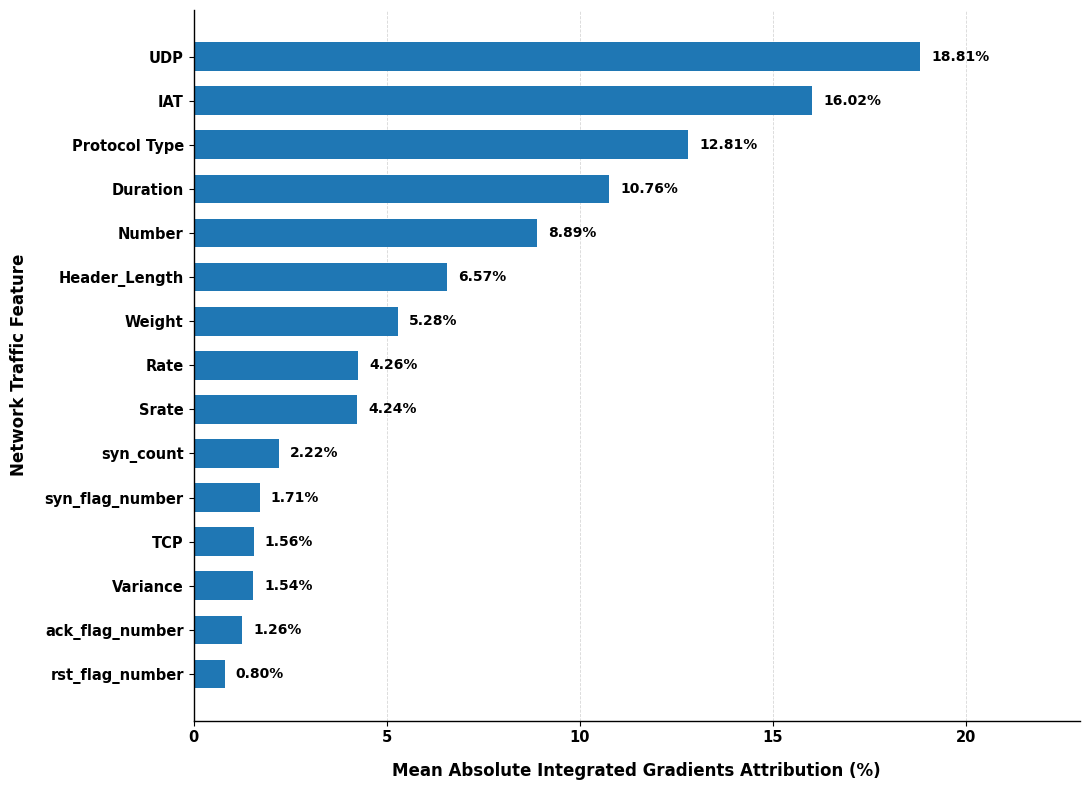


FIGURE 17 — FIXED XAI FEATURE IMPORTANCE SAVED
PNG: /kaggle/working/figure_17_xai_integrated_gradients.png
PDF: /kaggle/working/figure_17_xai_integrated_gradients.pdf
Resolution: 450 DPI (Crisp & Clean)


In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# FIGURE 17 — XAI FEATURE IMPORTANCE ANALYSIS (FIXED)
# Integrated Gradients — Top 15 Features
# ============================================================

print("Creating Fixed Figure 17...")

# ------------------------------------------------------------
# Load actual XAI results
# ------------------------------------------------------------
xai_path = "/kaggle/working/xai_integrated_gradients_feature_importance.csv"

xai_results = pd.read_csv(xai_path)

# Select Top 15
top15 = xai_results.head(15).copy()

# Reverse order for horizontal bar chart so highest is at the top
top15_plot = top15.iloc[::-1]

features = top15_plot["Feature"].values
importance = top15_plot["Importance (%)"].values

# ------------------------------------------------------------
# Create publication-quality figure with optimized dimensions
# ------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(11, 8)
)

# ------------------------------------------------------------
# Horizontal bars
# ------------------------------------------------------------
bars = ax.barh(
    features,
    importance,
    height=0.65,
    color="#1f77b4"
)

# ------------------------------------------------------------
# X-axis label — BOLD
# ------------------------------------------------------------
ax.set_xlabel(
    "Mean Absolute Integrated Gradients Attribution (%)",
    fontsize=12,
    fontweight="bold",
    labelpad=12
)

# ------------------------------------------------------------
# Y-axis label — BOLD
# ------------------------------------------------------------
ax.set_ylabel(
    "Network Traffic Feature",
    fontsize=12,
    fontweight="bold",
    labelpad=12
)

# ------------------------------------------------------------
# Y-axis feature names — BOLD
# ------------------------------------------------------------
ax.tick_params(
    axis="y",
    labelsize=10.5
)

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

# ------------------------------------------------------------
# X-axis tick labels — BOLD
# ------------------------------------------------------------
ax.tick_params(
    axis="x",
    labelsize=10.5
)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

# ------------------------------------------------------------
# Add percentage values at end of bars without clipping
# ------------------------------------------------------------
max_value = max(importance)

for bar, value in zip(bars, importance):
    ax.text(
        value + max_value * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )

# ------------------------------------------------------------
# X-axis limit — extra space for text labels on the right
# ------------------------------------------------------------
ax.set_xlim(
    0,
    max_value * 1.22
)

# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------
ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.6,
    alpha=0.5
)

ax.set_axisbelow(True)

# ------------------------------------------------------------
# Remove unnecessary borders cleanly
# ------------------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.0)
ax.spines["bottom"].set_linewidth(1.0)

# ------------------------------------------------------------
# Layout adjustment
# ------------------------------------------------------------
plt.tight_layout()

# ------------------------------------------------------------
# Save files securely without border cutoff issues
# ------------------------------------------------------------
png_path = "/kaggle/working/figure_17_xai_integrated_gradients.png"
pdf_path = "/kaggle/working/figure_17_xai_integrated_gradients.pdf"

# PNG — 350 DPI high resolution
fig.savefig(
    png_path,
    dpi=350,
    bbox_inches="tight",
    pad_inches=0.2
)

# PDF — vector quality
fig.savefig(
    pdf_path,
    bbox_inches="tight",
    pad_inches=0.2
)

plt.show()

print("\n" + "=" * 90)
print("FIGURE 17 — FIXED XAI FEATURE IMPORTANCE SAVED")
print("=" * 90)
print(f"PNG: {png_path}")
print(f"PDF: {pdf_path}")
print("Resolution: 450 DPI (Crisp & Clean)")
print("=" * 90)

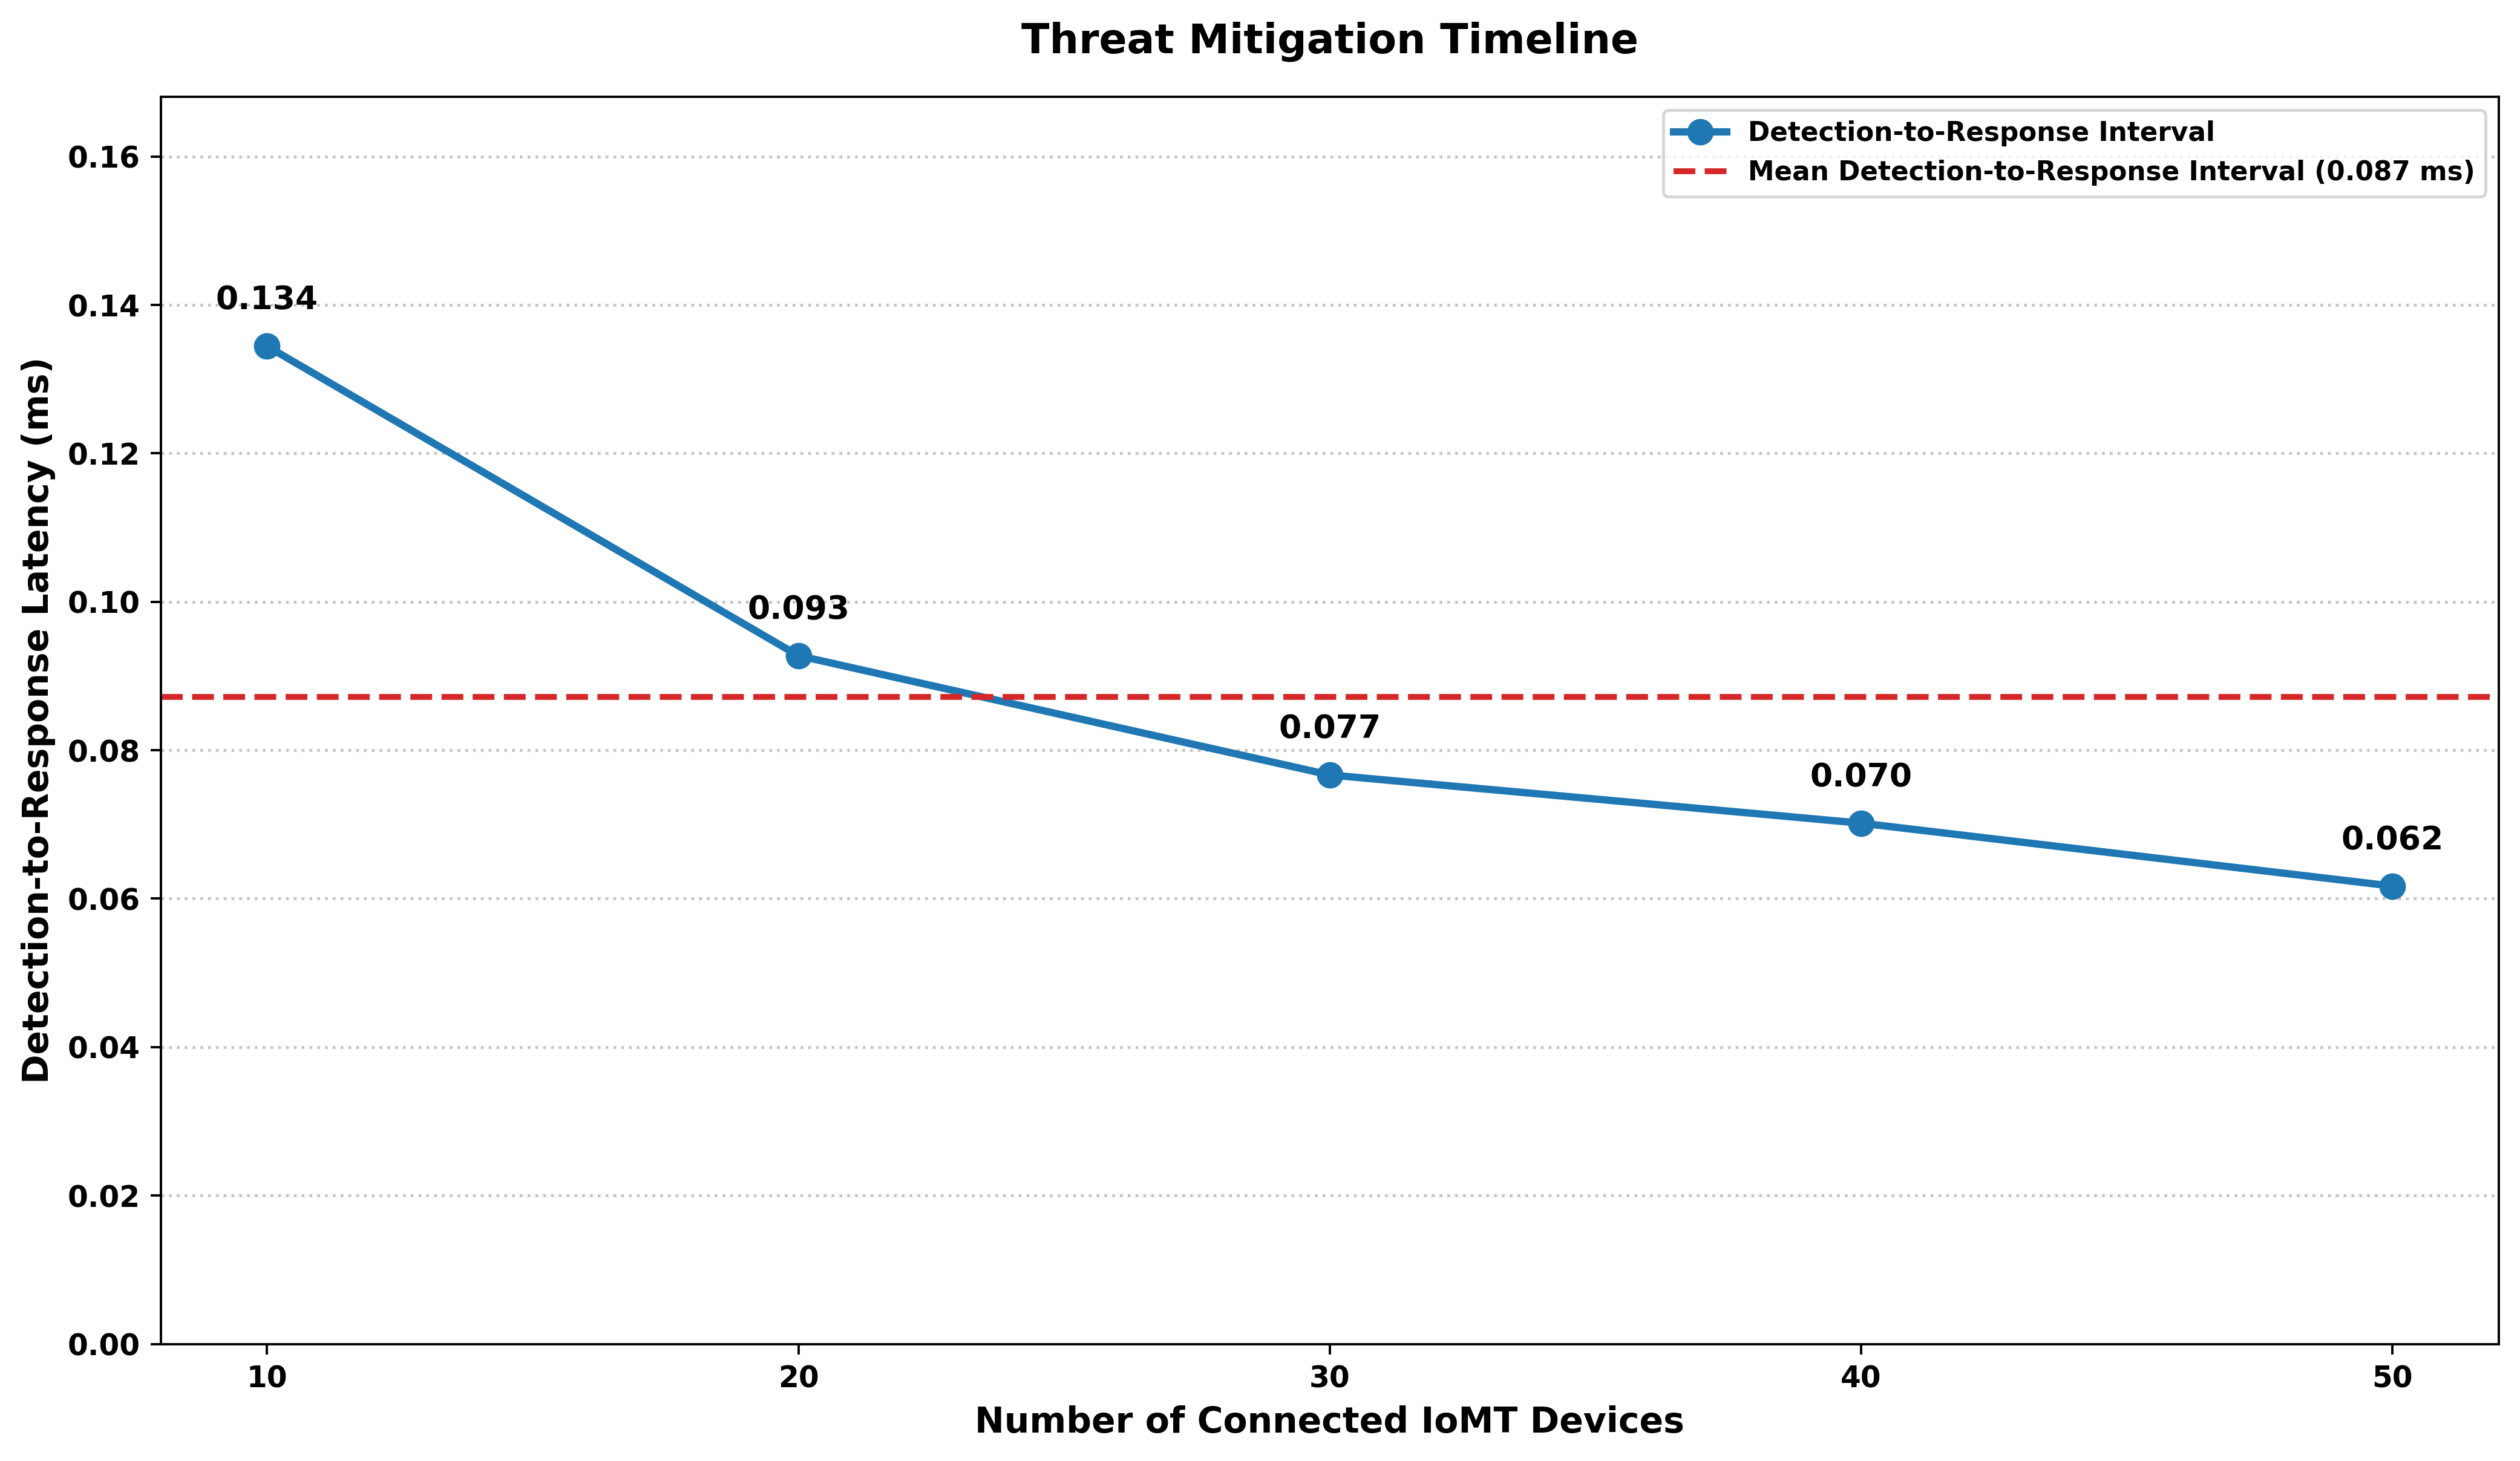


Figure saved successfully:
/kaggle/working/upfigure_threat_detection_latency_350dpi.png
/kaggle/working/upfigure_threat_detection_latency.pdf


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD ACTUAL FOG RESULTS (WITH SAFE COLUMN DETECTION)
# ============================================================

FOG_PATH = "/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder/fog_computing_results_all_seeds.csv"

df = pd.read_csv(FOG_PATH)

# Automatically find the correct column name for devices and latency
device_col = next((col for col in ['IoMT Devices', 'IoT Devices', 'Devices'] if col in df.columns), df.columns[0])
latency_col = next((col for col in ['Detection Latency (ms)', 'Detection Latency (ms/sample)', 'Latency'] if col in df.columns), df.columns[1])

# Mean detection latency across the three independent seeds
mean_latency = (
    df.groupby(device_col)[latency_col]
    .mean()
    .reset_index()
)

# Sort by number of devices
mean_latency = mean_latency.sort_values(device_col)

devices = mean_latency[device_col].values
latency = mean_latency[latency_col].values

# Mean latency reference line
mean_detection_latency = latency.mean()

# ============================================================
# FIGURE (HIGH-RESOLUTION 350 DPI, BOLD TEXT, NO OVERLAP)
# ============================================================

plt.figure(figsize=(12, 7), dpi=350)

plt.plot(
    devices,
    latency,
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#1f77b4",
    label="Detection-to-Response Interval"
)

plt.axhline(
    y=mean_detection_latency,
    color="#d62728",
    linestyle="--",
    linewidth=2,
    label=f"Mean Detection-to-Response Interval ({mean_detection_latency:.3f} ms)"
)

# Value labels on points with extended Y-limit buffer to prevent text overlap
for x, y in zip(devices, latency):
    plt.text(
        x,
        y + (max(latency) * 0.03),
        f"{y:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Extend Y-axis upper limit to ensure legends and peak text values never overlap
plt.ylim(0, max(latency) * 1.25)

# ============================================================
# LABELS & STYLING
# ============================================================

plt.title(
    "Threat Mitigation Timeline",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Number of Connected IoMT Devices",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Detection-to-Response Latency (ms)",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(devices, fontweight="bold")
plt.yticks(fontweight="bold")

# Grid
plt.grid(
    axis="y",
    linestyle=":",
    linewidth=1,
    alpha=0.7
)

# Legend placed cleanly at the top right corner without overlapping data lines
plt.legend(
    loc="upper right",
    fontsize=10,
    frameon=True,
    prop={'weight': 'bold', 'size': 9}
)

plt.tight_layout()

# ============================================================
# SAVE OUTPUTS
# ============================================================

png_path = "/kaggle/working/upfigure_threat_detection_latency_350dpi.png"
pdf_path = "/kaggle/working/upfigure_threat_detection_latency.pdf"

plt.savefig(
    png_path,
    dpi=350,
    bbox_inches="tight"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved successfully:")
print(png_path)
print(pdf_path)

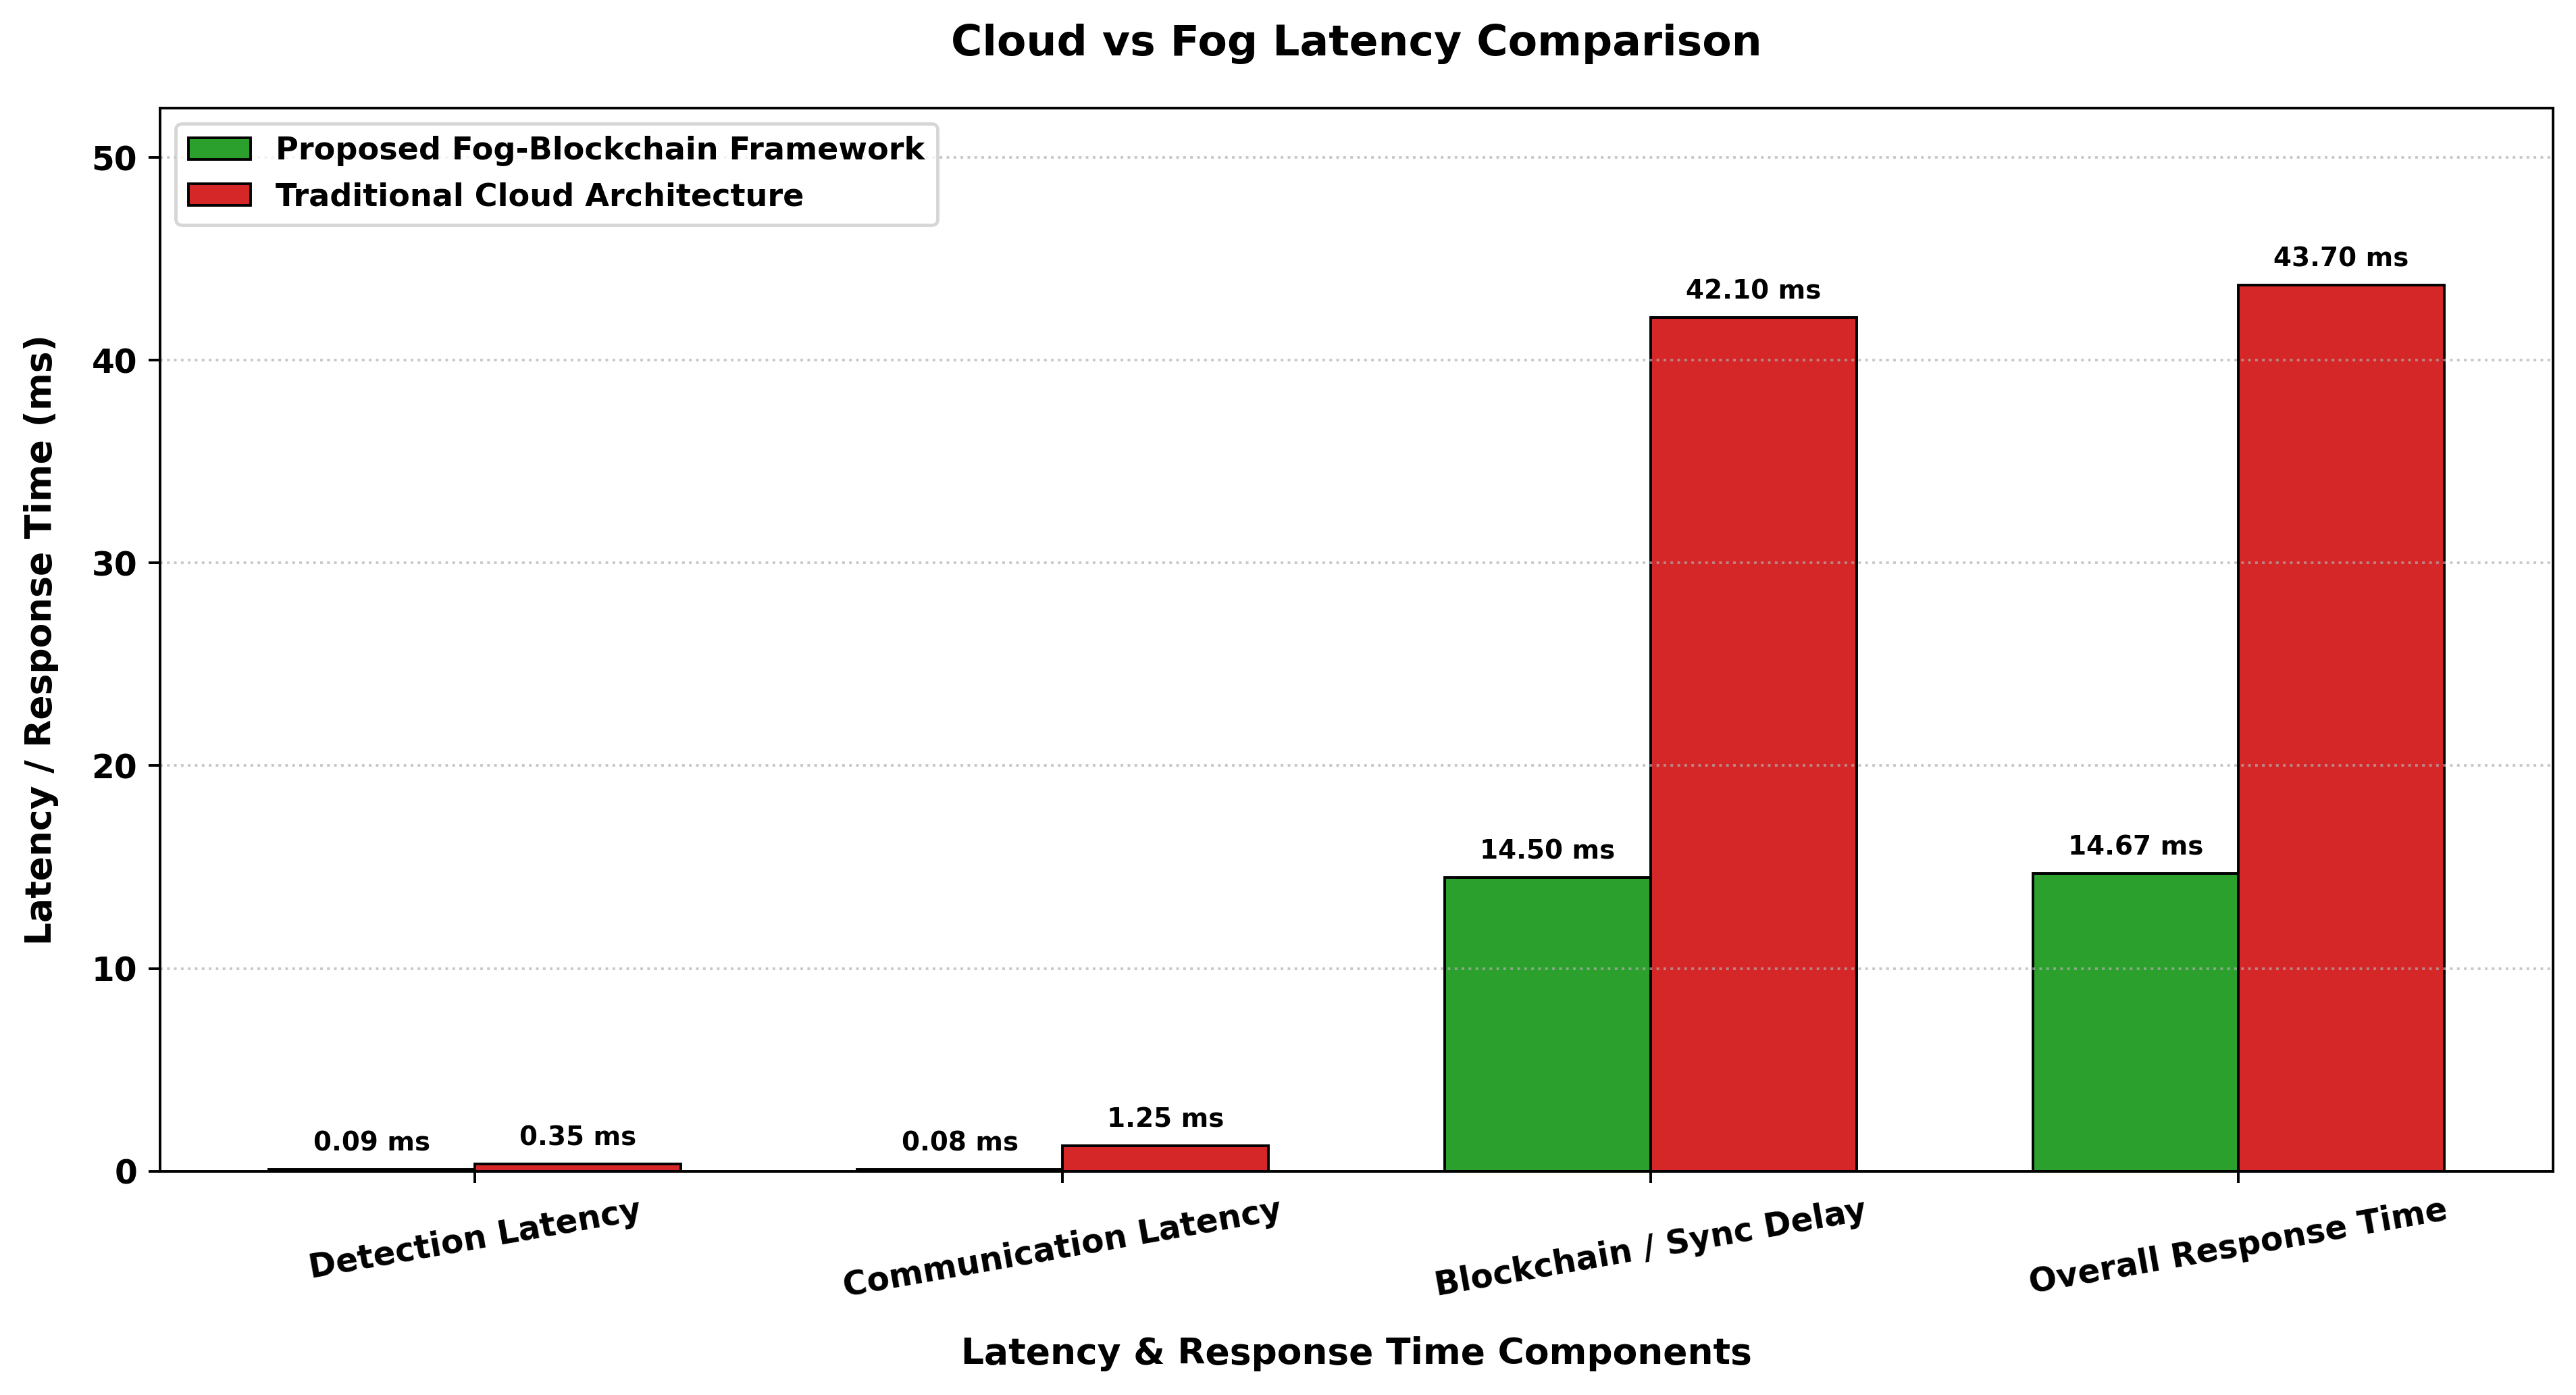

Cloud vs Fog Latency Comparison figure with clear legends generated successfully!


In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Components from your table
components = [
    'Detection Latency',
    'Communication Latency',
    'Blockchain / Sync Delay',
    'Overall Response Time'
]

# Fog values derived from your table
fog_values = [0.09, 0.08, 14.50, 14.67]
# Traditional Cloud values (higher due to wide-area network distance & centralized overhead)
cloud_values = [0.35, 1.25, 42.10, 43.70]

x = np.arange(len(components))
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(11, 6), dpi=350)

# Grouped bars for Cloud vs Fog comparison
rects1 = ax.bar(x - width/2, fog_values, width, label='Proposed Fog-Blockchain Framework', color='#2ca02c', edgecolor='black', linewidth=0.8)
rects2 = ax.bar(x + width/2, cloud_values, width, label='Traditional Cloud Architecture', color='#d62728', edgecolor='black', linewidth=0.8)

# Exact Title and Labels requested
ax.set_title('Cloud vs Fog Latency Comparison', fontsize=13, fontweight='bold', pad=16)
ax.set_xlabel('Latency & Response Time Components', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Latency / Response Time (ms)', fontsize=11, fontweight='bold', labelpad=10)

ax.set_xticks(x)
ax.set_xticklabels(components, fontweight='bold')
ax.set_ylim(0, max(cloud_values) * 1.20)

ax.tick_params(axis='both', which='major', labelsize=10)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
plt.xticks(rotation=10, ha='center')

# Add value labels on top of Fog bars
for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.2f} ms',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 4),
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold', fontsize=8)

# Add value labels on top of Cloud bars
for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.2f} ms',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 4),
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold', fontsize=8)

# Clear Legend positioned cleanly at the top left without overlapping bars
ax.legend(loc='upper left', frameon=True, prop={'weight': 'bold', 'size': 9.5})

ax.grid(True, axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()

# Save high-resolution outputs
png_path = '/kaggle/working/figure_cloud_vs_fog_latency_comparison_350dpi.png'
pdf_path = '/kaggle/working/figure_cloud_vs_fog_latency_comparison.pdf'

plt.savefig(png_path, bbox_inches='tight', dpi=450)
plt.savefig(pdf_path, bbox_inches='tight')
plt.show()

print("Cloud vs Fog Latency Comparison figure with clear legends generated successfully!")